# Radial velocity analysis of WASP-12b 

Guillermo de la Mata Núñez

**Universidad de La Laguna Exo & Exo 2025-2026 exercise 1**

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

This first exercise teaches you how to estimate the minimum planetary mass from radial velocity measurements using [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference).

**Exercise style:** 
- Use astropy constants, units, and unit conversions where possible.
- Carry out the calculations using posterior sample arrays instead of point estimates whenever possible. This ensures correct uncertainty propagation.


## 1.1 (The absolute basics of) radial velocities

A planet orbiting a star causes the star to [move around the star-planet barycentre](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/#/1). This leads to a periodic change in the star's position and velocity,
and the radial component of the star's velocity can be measured using [doppler spectroscopy](https://en.wikipedia.org/wiki/Doppler_spectroscopy). Radial velocity (RV) measurements are used to search for unknown planets and to estimate the minimum masses and orbital periods of known planets.

![Doppler shift vs time](Doppler_Shift_vs_Time.svg "Doppler shift vs time")


A planet with a mass $M_\mathrm{p}$ orbiting a star with a mass $M_\star$ with an orbital period $P$ leads to a periodic signal with a semi-amplitude of

$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

where $G$ is the [gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant), $e$ is the [orbital eccentricity](https://en.wikipedia.org/wiki/Orbital_eccentricity), and $i$ is the [orbital inclination](https://en.wikipedia.org/wiki/Orbital_inclination). After we estimate $P$, $K$, and $M_\star$ we can solve for the minimum planetary mass $M_\mathrm{p} \sin i$. The orbital period and RV semi-amplitude can be estimated directly from the RV signal, but the stellar mass needs to be estimated using other means.


## 1.2 (The absolute basics of) Bayesian parameter estimation

Measuring the RV semi-amplitude and the orbital period from RV measurements is a *parameter estimation* problem: we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties.

We take a [*Bayesian*](http://en.wikipedia.org/wiki/Bayesian_probability) approach to the parameter estimation, where we want to estimate the [*posterior probability*](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [*prior probabilities*](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by the [*Bayes' theorem*](http://en.wikipedia.org/wiki/Bayes%27_theorem) as

$$
P(\theta|D) = \frac{P(\theta) P(D|\theta)}{P(D)}, \qquad P(D|\theta) = \prod P(D_i|\theta),
$$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [*likelihood*](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [*normalising factor*](http://en.wikipedia.org/wiki/Marginal_likelihood) we don't need to bother with during MCMC-based parameter estimation. 

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead, so that

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

where we have omitted the $P(D)$ term from the posterior density.

Now we still need to decide our likelihood density. If we can assume normally distributed white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. 

This should be enough for these exercies, but you can find more information from [A primer about Bayesian statistics](https://ui.adsabs.harvard.edu/link_gateway/2018haex.bookE.149P/EPRINT_PDF) and the references therein.

## 2.1 Initialisation

In [1]:
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, median
from astropy.table import Table
from astropy.timeseries import LombScargle
from corner import corner

from pytransit.lpf.rvlpf import RVLPF

rc('figure', figsize=(13,4))

C:\Users\Usuario\anaconda3\envs\pytransit_env\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
C:\Users\Usuario\anaconda3\envs\pytransit_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.1 Read in the RV data 

The radial velocity measurements consist of mid-observation times, radial velocity values, and radial velocity measurement uncertainties (also called as 'errors'). We use the data from [Yee et al. (2019)](https://iopscience.iop.org/article/10.3847/2041-8213/ab5c16). The data is stored as a CDS table that can be read directly using `astropy.table.Table`.

In [2]:
rv_data = Table.read('data/wasp_12b_yee_2019.dat', format='ascii.cds')

It's important to understand what sort of data we're dealing with, so we begin by displaying the table header and the five first rows.

In [3]:
rv_data[:5]  

BJD,RVel,e_RVel
d,m / s,m / s
float64,float64,float64
2455521.959432,-136.635,2.534
2455543.089922,5.728,2.919
2455545.983884,-162.39,2.822
2455559.906718,141.616,2.345
2455559.917563,115.818,2.727


It's also useful to visualise directly what we're working with, so we next plot the radial velocity data and its uncertainties as a function of time.

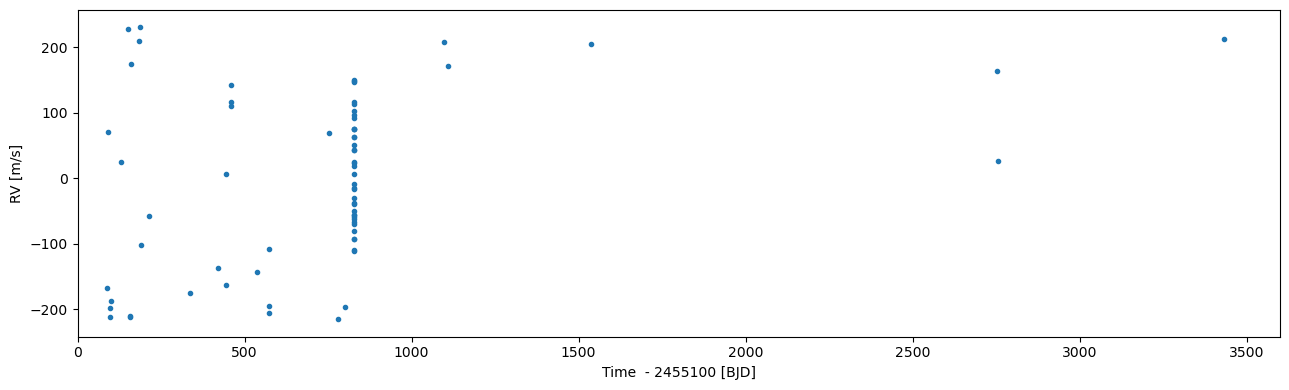

In [4]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(0, 3600))
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe the logic behind the time sampling of the RV observations.

- Answer. The time sampling of radial velocity observations is intentionally irregular and planned to detect periodic signals over a wide range of signals. The observations are taken at both short and long intervals to cover a wide range of possible periods, avoid aliasing, and ensure good phase coverage of the orbit. This also accounts for stellar noise and constraints like weather and target visibility, and it can be adjusted dynamically based on preliminary results to maximize the information gained.

2. Plot below the RV observations as a function of time focusing on the densely-sampled time-span.

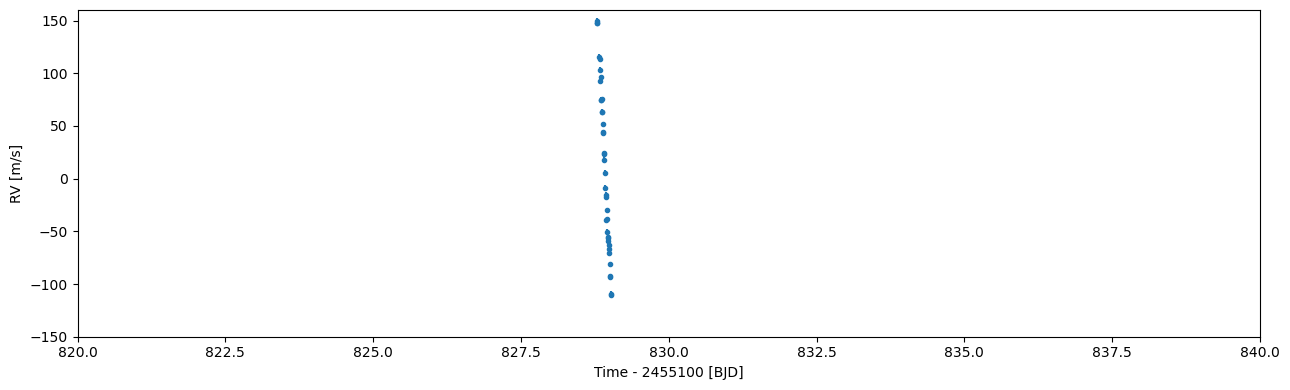

In [5]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(820, 840), ylim=(-150, 160))
fig.tight_layout()

## 2.2 Search for a radial velocity signal

First, we use a Lomb-Scargle periodigram to search for a sinusoidial radial velocity signal from the RV measurements. This is simple to do with `astropy.timeseries.LombScargle` class that is initialised with the mid-measurement times and the RV observations.

In [6]:
ls = LombScargle(rv_data['BJD'], rv_data['RVel'])

Next, we use the `LombScargle.autopower` to calculate the periodogram. We restrict the search to $0.5 < P < 5$ days.

In [7]:
frequency, power = ls.autopower(minimum_frequency=1/(5*u.d), maximum_frequency=2/u.d)
period = 1/frequency

In [8]:
best_period = period[argmax(power)]
best_period

<Quantity 1.09144998 d>

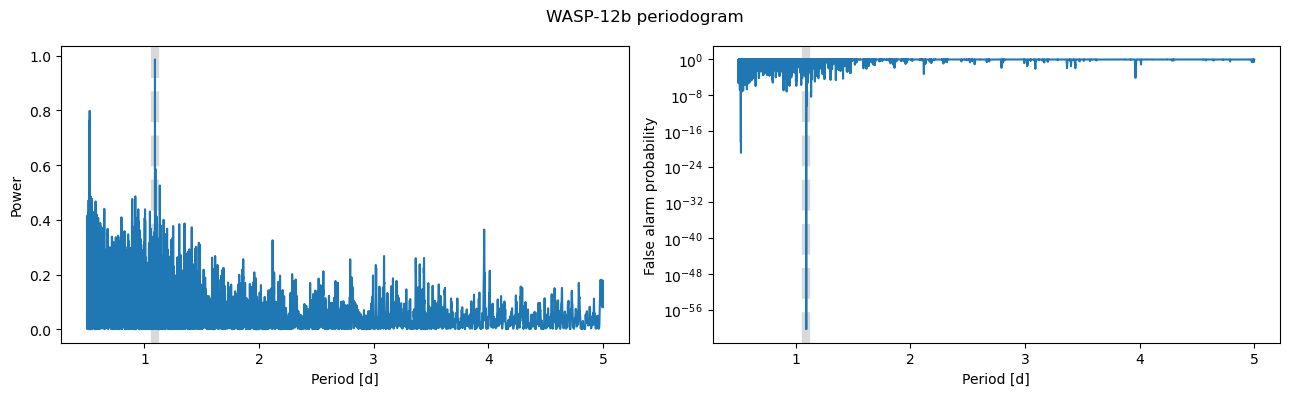

In [9]:
fig, axs = subplots(1, 2, figsize=(13,4))
axs[0].plot(period, power)
axs[1].semilogy(period, ls.false_alarm_probability(power))
[ax.axvline(best_period.value, c='k', ls='--', zorder=-1, lw=6, alpha=0.15) for ax in axs]
setp(axs, xlabel='Period [d]')
setp(axs[0], ylabel='Power')
setp(axs[1], ylabel='False alarm probability')
fig.suptitle('WASP-12b periodogram')
fig.tight_layout()

Let's see what happens when we plot the RV values folded over the best period.

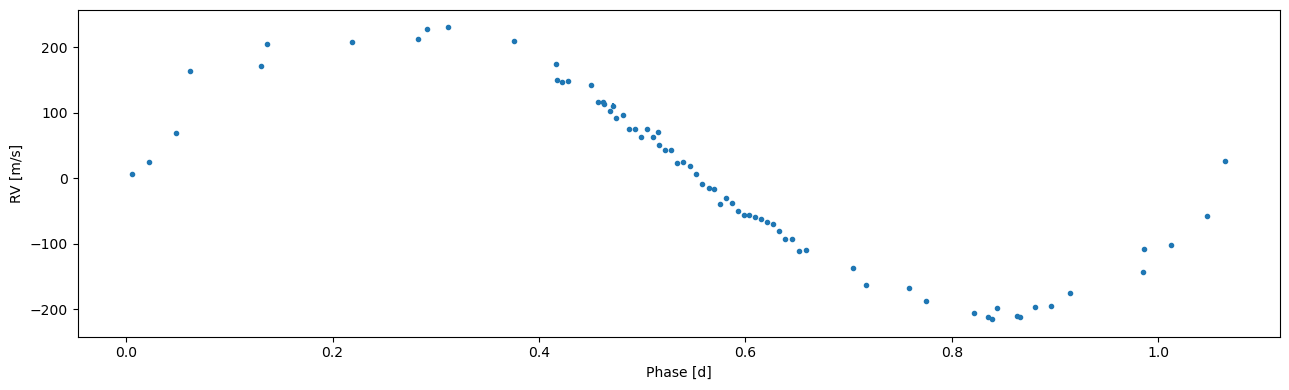

In [10]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] % best_period.value, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Phase [d]', ylabel='RV [m/s]')
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Describe what the Lomb-Scargle power and false alarm probability mean.

- Answer.
  
-The Lomb-Scargle power measures how strongly a periodic signal at a given frequency is present in unevenly sampled data, acting like a frequency-dependent good fit for a sinusoidal model, higher power indicate a stronger and more significant periodic component.

-The False Alarm Probability (FAP) quantifies how likely it is that a peak of that power could arise purely from random noise rather than a real signal, low FAP means the detected periodicity is unlikely to be due to chance and is more likely to be real.


## 2.3 Radial velocity modelling

Now when we know the RV data contains a suspicious signal, we can model it to study what sort of an object is causing it. The two most important parameters we're interested are the orbital period and radial velocity semiamplitude (K). The RV semiamplitude will give us the lower limit of the object's mass ($m\sin i$) which will then tell us whether we're dealing with a planet or something else.

### Initialise the model

In [11]:
lpf = RVLPF('WASP-12b', 1, rv_data['BJD'], rv_data['RVel'], rv_data['e_RVel'])

In [12]:
lpf.ps

[  0 |G| tc_1           N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 1.0)                      [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 1.0)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     N(μ = 0.0, σ = 1.0)                      [    -inf ..      inf]]

The parameters are

- `tc_1`: transit center [BJD]
- `p_1`: orbital period [d]
- `secw_1`: $\sqrt{e} \cos\omega$, where $e$ is the eccentricity and $\omega$ the argument of periastron
- `sesw_1`: $\sqrt{e} \sin\omega$
- `rv_shift_0`: systemic velocity [m/s]
- `rv_err_0`: additional white noise [m/s]
- `rv_k_1` RV semiamplitude [m/s]
- `rv_slope`: additional linear slope

### Set the parameter priors

Bayesian inference requires a prior probability distribution for each of our model parameters. These "priors" can be based on previous studies, theoretical expectations, or more generally in our beliefs on what values the parameters can take.

In this case we use two priors: a normal prior (NP) and a uniform prior (UP). The normal prior models our prior belief using a normal distribution with a known mean and standard deviation, while the uniform prior says that the paramer can take any value between a minimum and maximum boundary.

In [13]:
lpf.set_prior('tc_1', 'NP', 2458480.65, 0.02) # Normal prior (mean, sigma)
lpf.set_prior('p_1', 'NP', 1.09, 0.1)
lpf.set_prior('rv_shift_0', 'NP', 0.0, 10)
lpf.set_prior('rv_err_0', 'UP', 0.0, 30.0) # Uniform prior (min, max)
lpf.set_prior('rv_k_1', 'UP', 0.0, 300)
lpf.set_prior('rv_slope_1', 'UP', 0.0, 1e-5)

In [14]:
lpf.ps

[  0 |G| tc_1           N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.09, σ = 0.1)                     [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 10.0)                     [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 30.0)                     [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 300)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     U(a = 0.0, b = 1e-05)                    [    -inf ..      inf]]

### Fit the model to the data

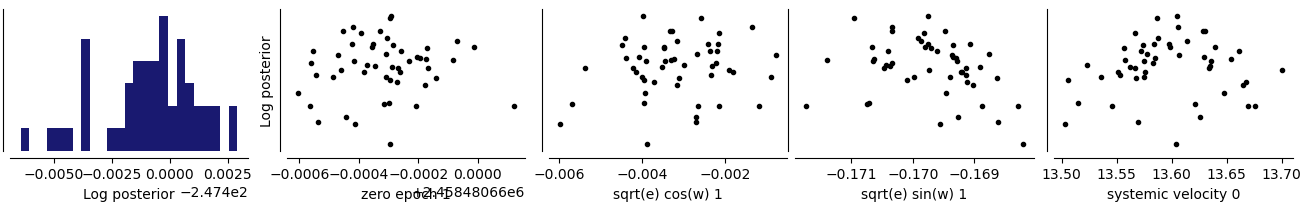

In [15]:
lpf.optimize_global(2000)

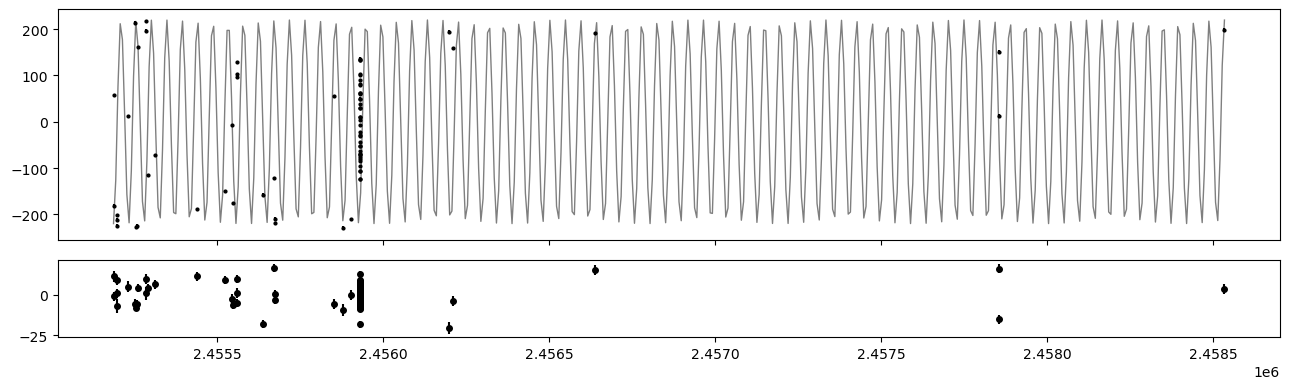

In [16]:
lpf.plot_rv_vs_time();

C:\Users\Usuario\anaconda3\envs\pytransit_env\lib\site-packages\pytransit\lpf\rvlpf.py:370: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  axs[0].errorbar(phase[m], rvs[m], self._rvea[m], fmt='o', marker=markers[iid],


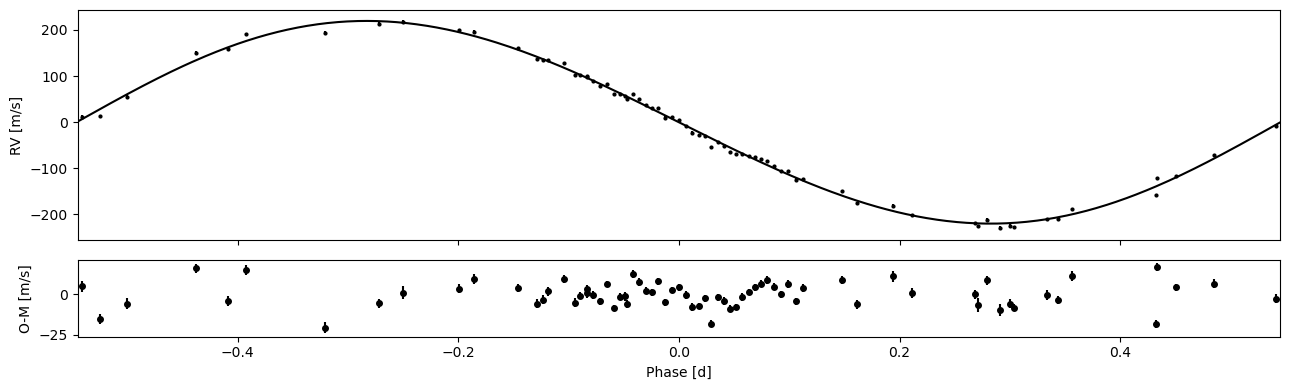

In [17]:
lpf.plot_rv_vs_phase(0);

### Estimate the parameter posterior distributions using MCMC

We estimate the [posterior probability distributions](https://en.wikipedia.org/wiki/Posterior_probability) of our model parameters using [Markov Chain Monte Carlo sampling](https://twiecki.io/blog/2015/11/10/mcmc-sampling). The sampling can be done using the `RVLPF.sample_mcmc` method after a global optimisation run has been finished. The `sample_mcmc` method uses the [*emcee*](https://emcee.readthedocs.io/en/stable) sampler under the hood.

We give `RVLPF.sample_mcmc` the number of MCMC steps to take (`niter`), a thinning factor (`thin`), and a number of repeats (`repeats`). This makes the sampler run first one round of `niter` steps, restarts the sampler from the last step of the previous run, and run again `niter` steps. This is the same as running the sampler for `2 x niter` and keeping only the second half of the steps. The first half is treated as a [warm-up period](https://stats.stackexchange.com/questions/88819/mcmc-methods-burning-samples) for the sampler and discarded. In general, the sampler is run `repeats x niter` steps in total, and only the last `niter` steps are retained.

The thinning factor tells the sampler to store only every $n$th step. In our case, we're storing only every 10th step. Thinning is a way to try to store only statistically independent samples, but is [not really necessary](https://besjournals.onlinelibrary.wiley.com/doi/pdf/10.1111/j.2041-210X.2011.00131.x). However, we'll do it to keep the number of samples low (there's no point in storing a large number of dependent samples either).

In [18]:
lpf.sample_mcmc(niter=2000, thin=10, repeats=2)

MCMC sampling: 100%|██████████| 2/2 [00:28<00:00, 14.31s/it] 


The *emcee* sampler uses an ensemble of MCMC chains to sample the posterior. This means that we have many chains running in parallel. We can plot the traces of each chain to see how the chain population behaves in time.

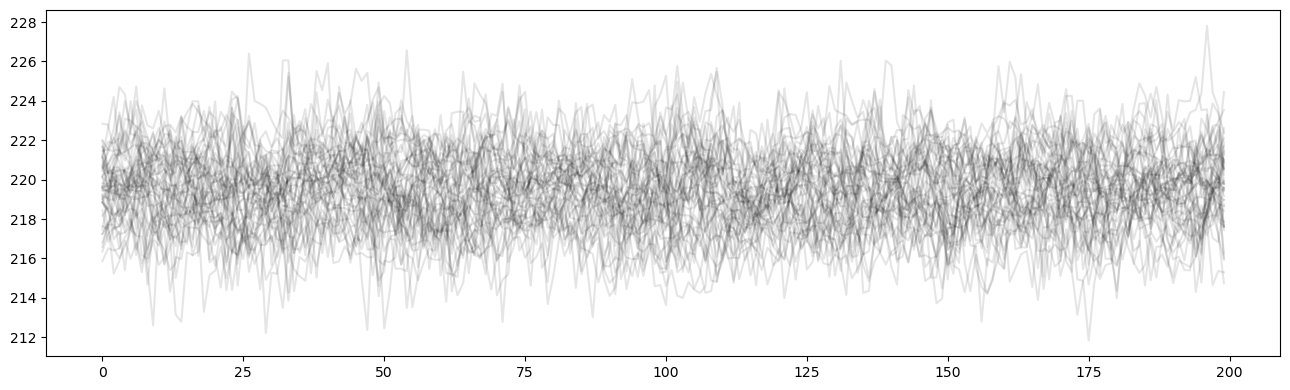

In [19]:
lpf.plot_mcmc_chains(6);

### Plot the model posterior

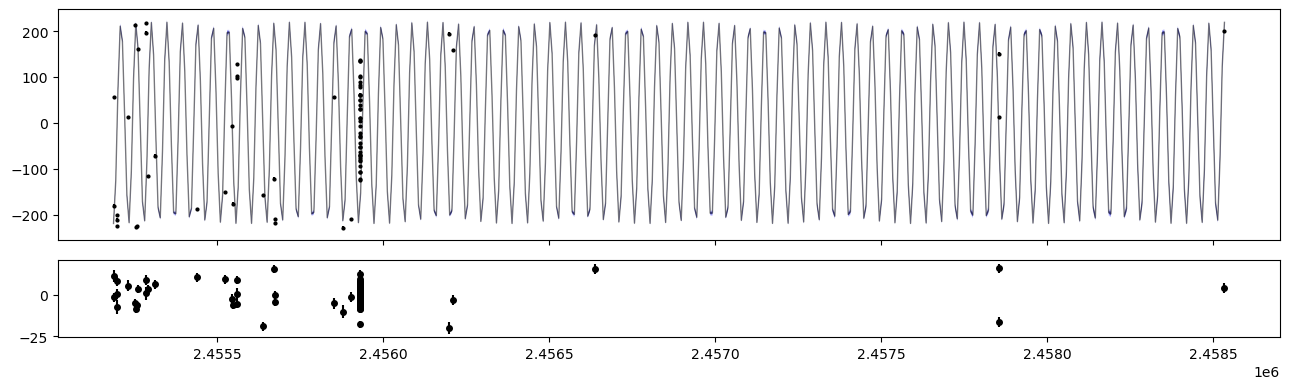

In [20]:
lpf.plot_rv_vs_time('mcmc');

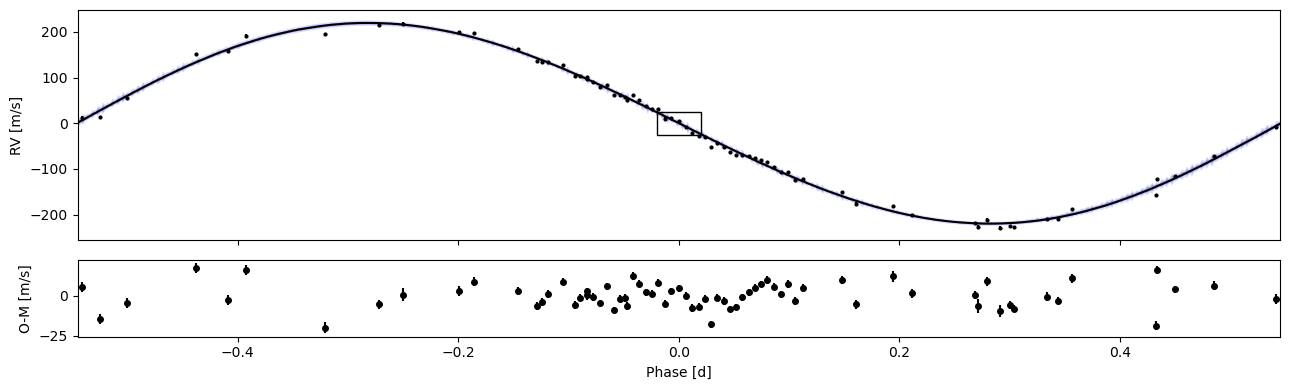

In [21]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
fig.axes[0].add_patch(Rectangle((-.02, -25), 0.04, 50, fill=False));

When we zoom a little bit, we can see that we're now actually plotting the probability density of the model. The black line corresponds to the median of the model posterior, and the two shades to the 68% and 95% central posterior limits.

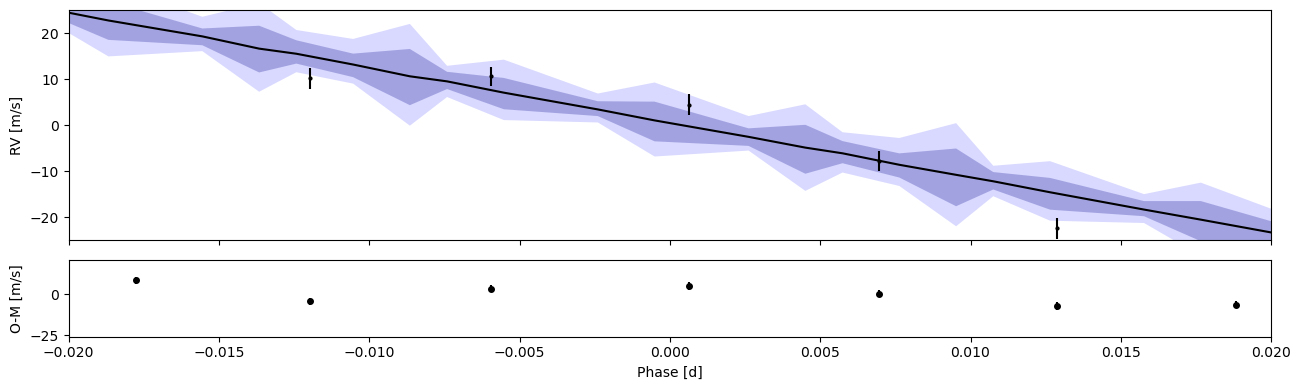

In [22]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
setp(fig.axes[0], xlim=(-0.02, 0.02), ylim=(-25,25));

### Plot the parameter posteriors

In [23]:
df = lpf.posterior_samples()
df

,tc_1,p_1,secw_1,sesw_1,rv_shift_0,rv_err_0,rv_k_1,rv_slope_1
0,2.458481e+06,1.091423,-0.002214,-0.168255,11.831512,7.661665,219.032972,5.728087e-06
1,2.458481e+06,1.091424,-0.008474,-0.173462,12.230300,7.784041,219.577407,5.253149e-06
2,2.458481e+06,1.091423,-0.015918,-0.183612,11.846847,7.982072,220.638510,7.823028e-06
3,2.458481e+06,1.091421,0.006385,-0.150114,11.837866,7.609854,219.259291,5.896233e-06
4,2.458481e+06,1.091420,0.004042,-0.140410,11.710463,7.658050,218.204792,6.391718e-06
...,...,...,...,...,...,...,...,...
9995,2.458481e+06,1.091423,0.082020,-0.047759,13.621422,7.200997,219.648591,5.141858e-07
9996,2.458481e+06,1.091423,0.083166,-0.116219,14.463754,6.924771,219.864760,1.509527e-06
9997,2.458481e+06,1.091423,0.056456,-0.110616,13.961668,7.207328,219.524479,2.268124e-06
9998,2.458481e+06,1.091423,0.073825,-0.092521,14.723326,7.942149,219.609644,3.753772e-06


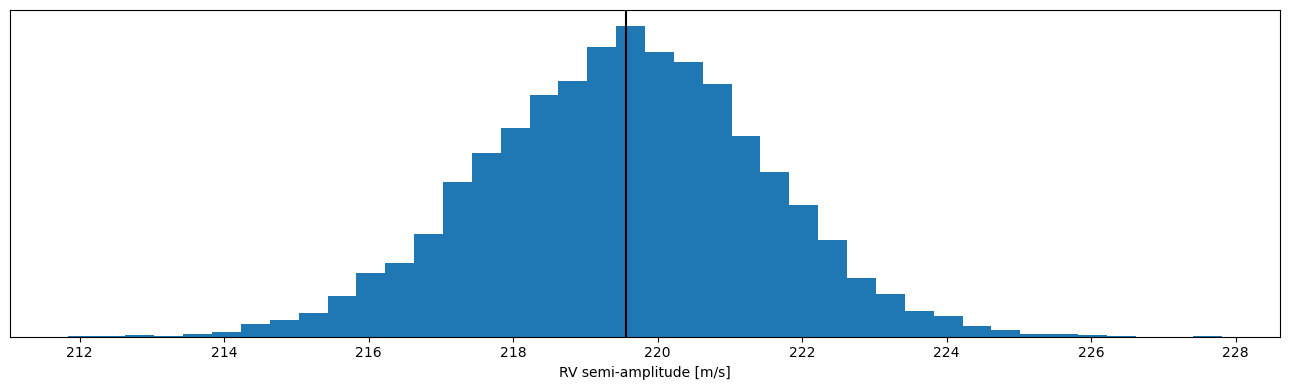

In [24]:
fig, ax = subplots()
ax.hist(df.rv_k_1, bins=40)
ax.axvline(median(df.rv_k_1), c='k')
setp(ax, xlabel='RV semi-amplitude [m/s]', yticks=[])
fig.tight_layout()

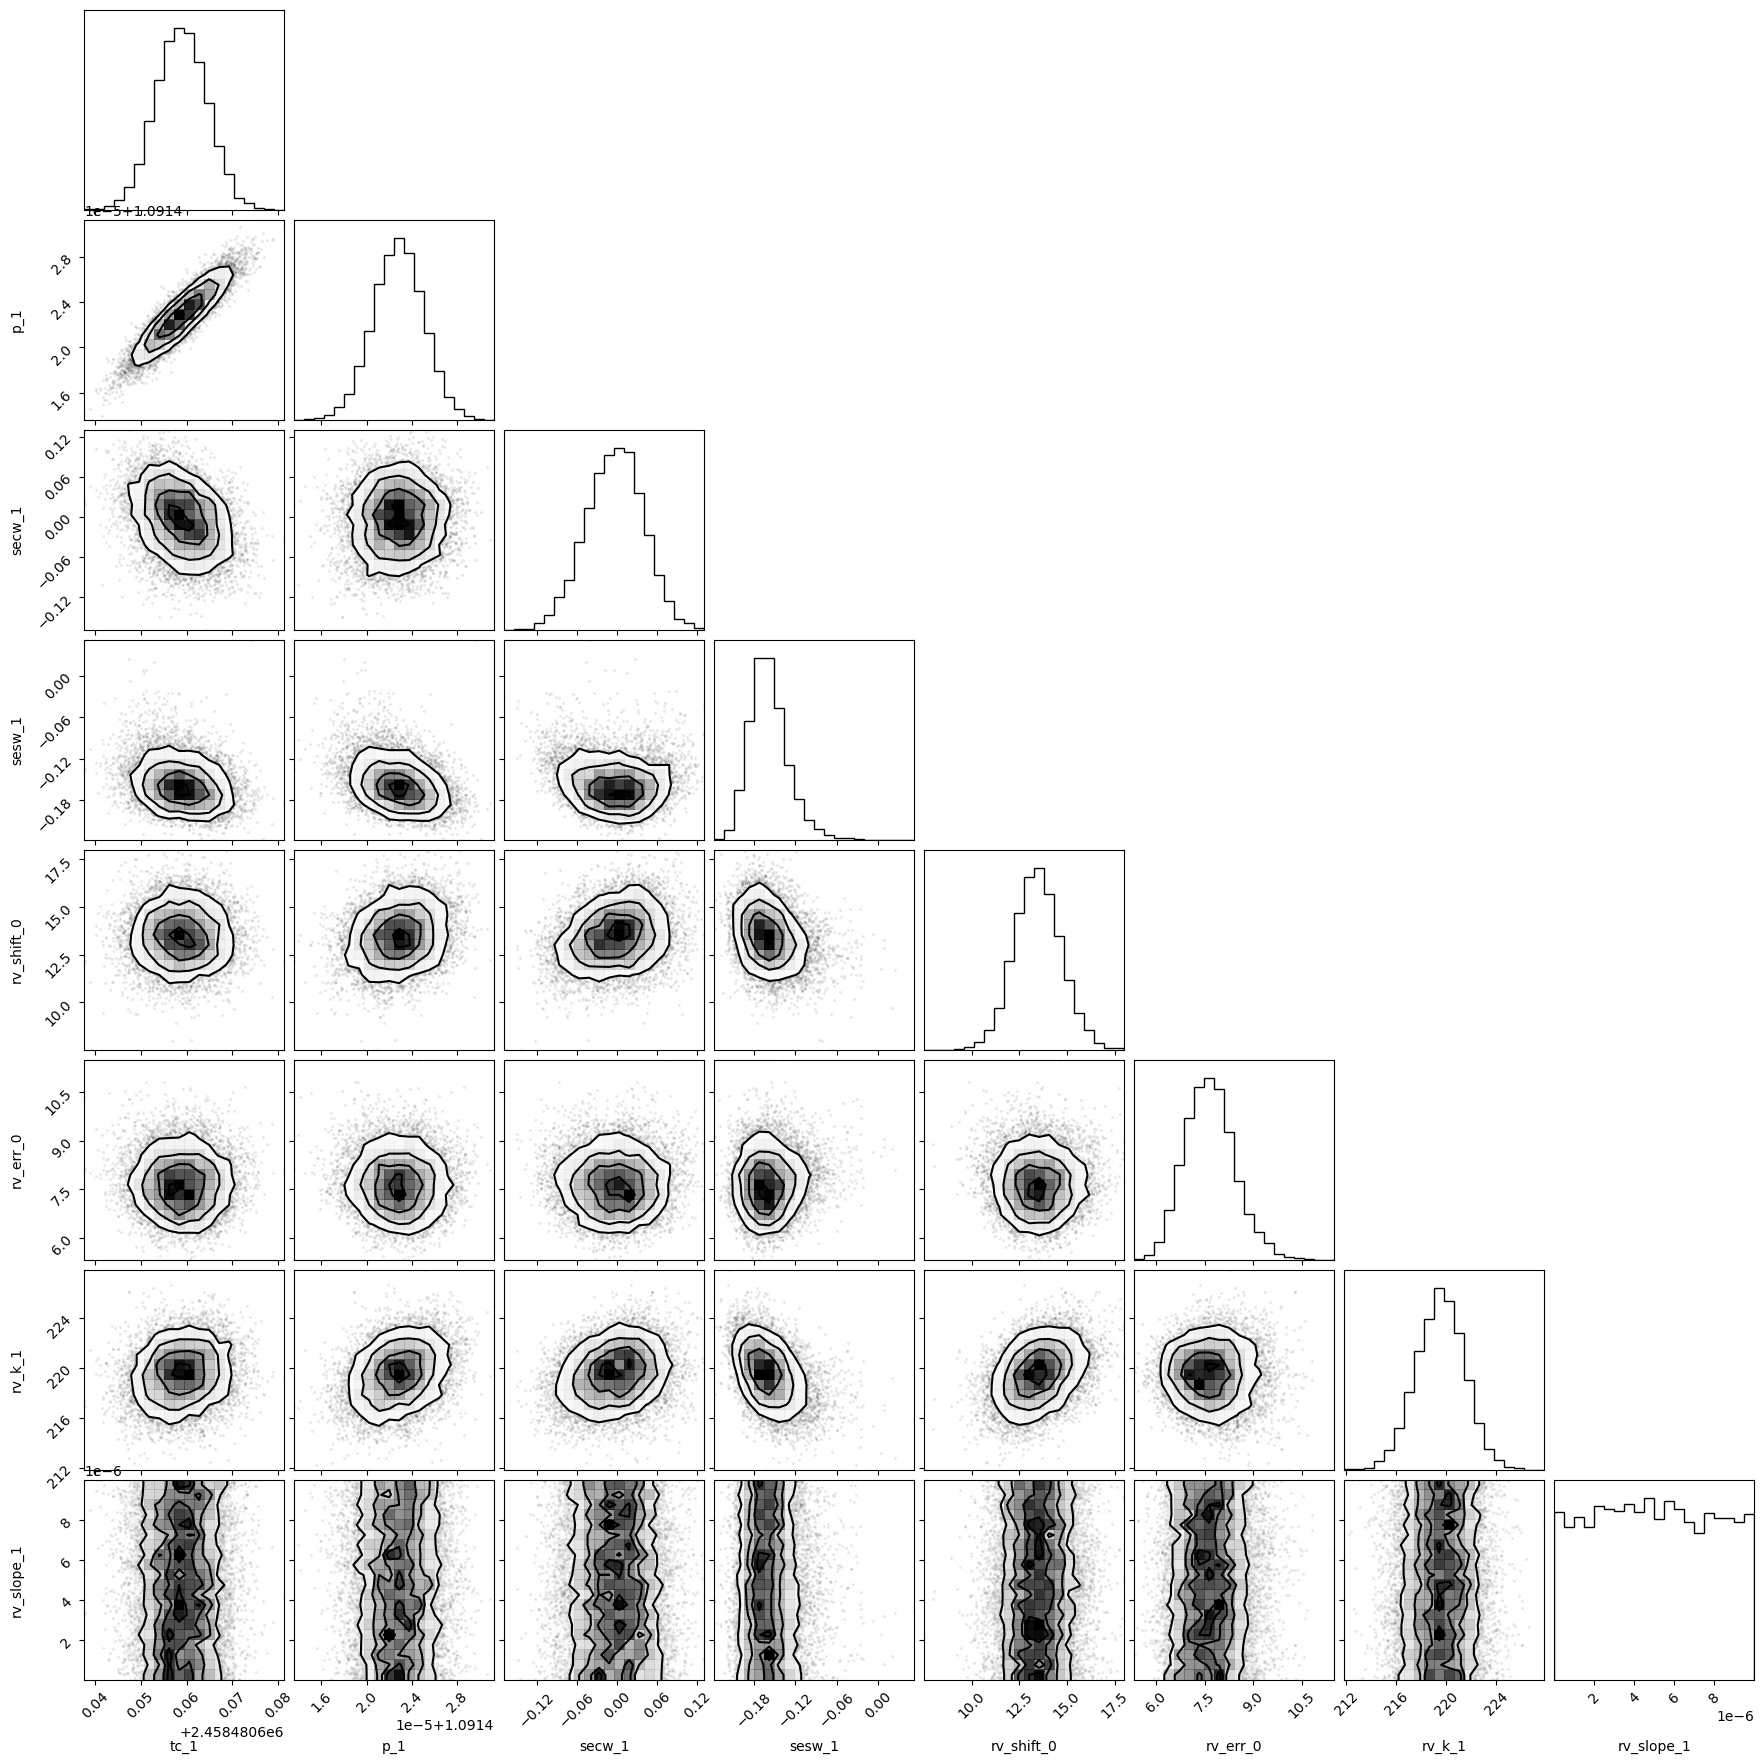

In [25]:
corner(df.values, labels=df.columns);

### <span style="color:darkblue">Questions and exercises</span>

1. What is the posterior density for the minimum mass ($m\sin i$) of WASP-12b? You can derive this from the RV semi-amplitude (K), orbital period (p), and the host star mass.

Derive the equation for the minimum mass, do the calculations using posterior samples, report both the mass median and its 68th percentile uncertainties, and plot the distribution. Use astropy constants, units, and unit conversions where needed.

Starting from the RV semi-amplitude equation:

$$K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_p \sin i}{(M_\star + M_p)^{2/3}} \frac{1}{(1-e^2)^{1/2}}$$

Assuming $M_p \ll M_\star$ so that $(M_\star + M_p)^{2/3} \approx M_\star^{2/3}$, and a circular orbit $e = 0$ so that $(1-e^2)^{1/2} = 1$:

$$K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_p \sin i}{M_\star^{2/3}}$$

Solving for $M_p \sin i$:

$$M_p \sin i = K \cdot M_\star^{2/3} \cdot \left(\frac{P}{2\pi G}\right)^{1/3}$$

M_p sin i = 1.36 +0.01 / -0.01 M_jup


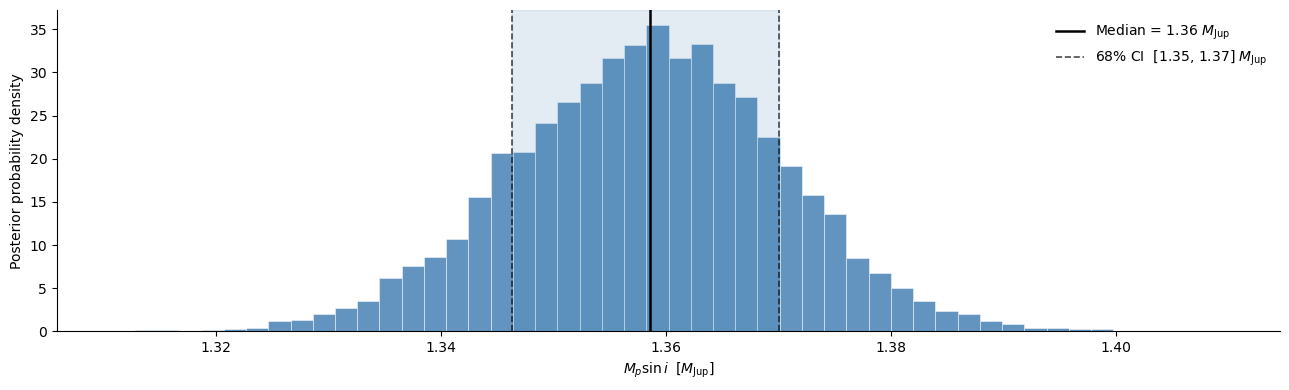

In [30]:

#Minimum mass of WASP-12b
from astropy.constants import G, M_sun, M_jup

# Stellar mass (Hebb et al. 2009)
M_star = 1.35 * M_sun

# Posterior samples from MCMC
K = df['rv_k_1'].values * (u.m / u.s)
P = df['p_1'].values * u.day

# Minimum mass from the RV mass function (circular orbit, M_p << M_star)
M_min = (K * (P / (2 * np.pi * G))**(1/3) * M_star**(2/3)).to(M_jup)

# Median and 68% credibility interval
med = median(M_min.value)
lo  = med - np.percentile(M_min.value, 16)
hi  = np.percentile(M_min.value, 84) - med

print(f"M_p sin i = {med:.2f} +{hi:.2f} / -{lo:.2f} M_jup")

#Plot
fig, ax = subplots()

ax.hist(M_min.value, bins=50,
        color='steelblue', edgecolor='white', linewidth=0.4,
        alpha=0.85, density=True)

ax.axvline(med,       c='k', lw=1.8,
           label=f'Median = {med:.2f} $M_{{\\rm Jup}}$')
ax.axvline(med - lo,  c='k', lw=1.2, ls='--', alpha=0.7)
ax.axvline(med + hi,  c='k', lw=1.2, ls='--', alpha=0.7,
           label=f'68% CI  [{med-lo:.2f}, {med+hi:.2f}] $M_{{\\rm Jup}}$')

ax.axvspan(med - lo, med + hi, color='steelblue', alpha=0.15)

ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, fontsize=10)

setp(ax,
     xlabel=r'$M_p \sin i \;\; [M_{\rm Jup}]$',
     ylabel='Posterior probability density')

fig.tight_layout()

2. What can you tell about WASP-12b as a planet based on its minimum mass and orbital period?

- Answer.
  With an orbital period of $P \approx 1.09$ days and a minimum mass of
  $M_p \sin i = 1.36 \pm 0.01 \, M_{\rm Jup}$, WASP-12b can be considered a **hot Jupiter**.

  The short period places the planet at only $\sim 0.023$ AU from its host star, approx 3 stellar radii, where it receives extreme stellar irradiation
  ($T_{\rm eq} \sim 2500$ K) and is subject to strong tidal forces. At this separation, the planet
  is expected to be tidally locked, always showing the same face to the star.

  The minimum mass of $\sim 1.36 \, M_{\rm Jup}$ confirms it is a gas giant, massive
  enough to have retained its hydrogen and helium envelope. Since $M_p \sin i$ is a
  lower limit on the true mass, the planet is at least this massive, and the transit detection confirms $\sin i \approx 1$, so this is
  essentially the true mass.

  Combining both properties, WASP-12b is a highly irradiated giant planet likely
  experiencing atmospheric escape and tidal orbital decay, consistent with the
  observed shrinking of its orbital period (Yee et al. 2020).

3. We parameterise the model using ($\sqrt{e}\sin\omega$, $\sqrt{e}\cos\omega$) instead of ($e$, $\omega$). This parameterisation is more efficient to sample with an MCMC sampler, but means we need to take some extra steps to get the eccentricity and argument of periastron samples. Write below the equations you need to use to map the sampling parameters to $e$ and $\omega$?

$s_1 = \sqrt{e}\sin\omega$ and $s_2 = \sqrt{e}\cos\omega$ will be the sampling parameters. We can recover $e$ and $\omega$ as follows.

Squaring and summing both parameters:

$$s_1^2 + s_2^2 = e\sin^2\omega + e\cos^2\omega = e(\sin^2\omega + \cos^2\omega) = e$$

Therefore:

$$e = s_1^2 + s_2^2$$

Dividing $s_1$ by $s_2$:

$$\frac{s_1}{s_2} = \frac{\sqrt{e}\sin\omega}{\sqrt{e}\cos\omega} = \tan\omega$$

Therefore:

$$\omega = \arctan\left(\frac{s_1}{s_2}\right)$$

In practice we use $\text{arctan2}(s_1, s_2)$ instead of $\arctan(s_1/s_2)$ to correctly recover the quadrant of $\omega \in (-\pi, \pi]$.

This parameterisation is preferred over $(e, \omega)$ directly because the space $(s_1, s_2)$ is continuous and well-defined at $e = 0$ : when the orbit is circular, $\omega$ becomes undefined and MCMC samplers struggle to explore that region efficiently. By sampling in $(s_1, s_2)$ instead, the sampler can cross through $e = 0$ smoothly without any singularity.

In [27]:
e = df['secw_1']**2 + df['sesw_1']**2
omega = np.arctan2(df['sesw_1'], df['secw_1'])

4. Derive $e$ and $\omega$ from the MCMC samples and plot their histograms.

We derive $e$ and $\omega$ from the MCMC posterior samples using the equations above, and plot their distributions.

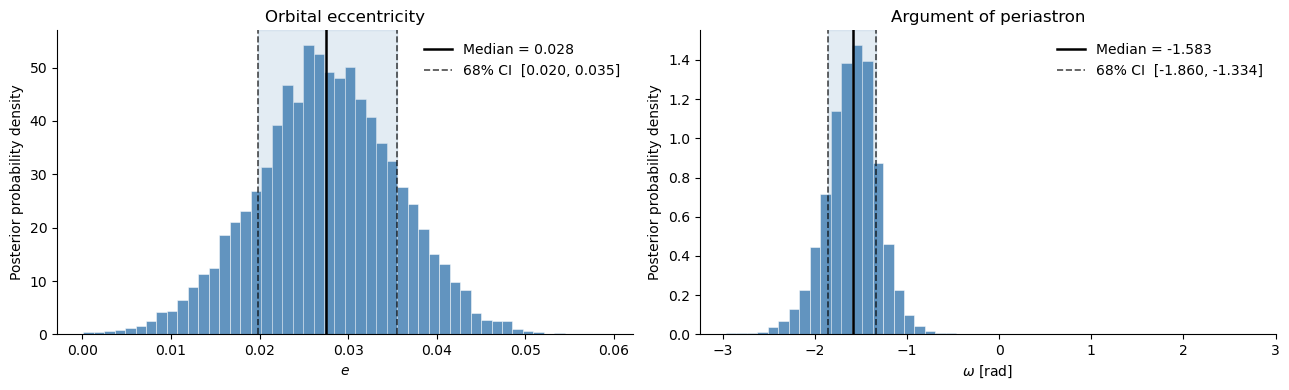

In [28]:
#Derive eccentricity and argument of periastron
e     = df['secw_1']**2 + df['sesw_1']**2
omega = np.arctan2(df['sesw_1'], df['secw_1'])

#Plot
fig, axs = subplots(1, 2, figsize=(13, 4))

for ax, samples, label, title in zip(
    axs,
    [e, omega],
    [r'$e$', r'$\omega$ [rad]'],
    ['Orbital eccentricity', 'Argument of periastron']
):
    med = np.median(samples)
    lo  = med - np.percentile(samples, 16)
    hi  = np.percentile(samples, 84) - med

    ax.hist(samples, bins=50,
            color='steelblue', edgecolor='white', linewidth=0.4,
            alpha=0.85, density=True)
    ax.axvline(med,       c='k', lw=1.8,
               label=f'Median = {med:.3f}')
    ax.axvline(med - lo,  c='k', lw=1.2, ls='--', alpha=0.7)
    ax.axvline(med + hi,  c='k', lw=1.2, ls='--', alpha=0.7,
               label=f'68% CI  [{med-lo:.3f}, {med+hi:.3f}]')
    ax.axvspan(med - lo, med + hi, color='steelblue', alpha=0.15)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=10)
    setp(ax, xlabel=label, ylabel='Posterior probability density', title=title)

fig.tight_layout()

The plot for $e$ is consistent with a circular orbit, the distribution 
peaks close to zero and the 68% credibility interval is very narrow. This justifies 
the assumption of $e = 0$ used in the minimum mass derivation above.

The argument of periastron $\omega$ is essentially unconstrained (flat distribution 
across $(-\pi, \pi \ ]$ ), which is expected when the eccentricity is consistent with 
zero, if the orbit is circular, $\omega$ has no physical meaning and the posterior 
simply reflects the prior.

5. What would be the posterior RV semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days?

We reuse the RV semi-amplitude equation, now solving for $K$ instead of $M_p \sin i$, using an Earth-mass planet ($M_p = M_\oplus$) with an orbital period of $P = 365$ days orbiting WASP-12:

$$K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_p \sin i}{M_\star^{2/3}}$$

We take the stellar mass as a fixed value
($M_\star = 1.35 \, M_\odot$, Hebb et al. 2009). We assume
$\sin i = 1$ to obtain the maximum possible semi-amplitude.

In [29]:
#RV semi-amplitude of an Earth-mass planet
from astropy.constants import M_earth

M_p     = 1.0 * M_earth
P_earth = 365.0 * u.day

K_earth = ((2 * np.pi * G / P_earth)**(1/3) * M_p / M_star**(2/3)).to(u.m/u.s)

print(f"RV semi-amplitude of an Earth-mass planet at 365 days:")
print(f"  K = {K_earth:.4f}")
print()
print(f"For comparison:")
print(f"WASP-12b K ~ {median(df['rv_k_1'].values):.1f} m/s")

RV semi-amplitude of an Earth-mass planet at 365 days:
  K = 0.0733 m / s

For comparison:
WASP-12b K ~ 219.6 m/s


---

<center>&copy;2026 Hannu Parviainen</center>